# INCOMPLETO!!!

# Operações Morfológicas

Transformações morfológicas são operações que podem ajudar a melhorar a aparência de uma imagem binária. baseadas na forma da imagem. Normalmente, são realizadas em imagens binárias. Elas precisam de duas entradas: uma é a nossa imagem original e a segunda é chamada de elemento estruturante (ou *kernel*), que decide a natureza da operação. 

Os dois operadores morfológicos mais comuns são *Erosion* e *Dilation*:

* **Erosion:** utilizado para separar ou reduzir as regiões brancas de uma imagem. Ela pode ser útil para remover pequenos artefatos de ruído.
* **Dilation:** utilizado para aumentar ou mesclar regiões brancas de uma imagem. Ela pode ser usada para preencher pequenos buracos e lacunas.

## Elementos Estruturantes
Em processamento de imagem e visão computacional, um elemento estruturante (ou structuring element, em inglês) é uma ferramenta conceitual crucial usada em operações de morfologia matemática. Ele serve como uma matriz ou padrão que ajuda a definir a vizinhança de um pixel específico em operações como erosão, dilatação, abertura e fechamento.

Elementos estruturantes podem assumir várias formas, dependendo da aplicação. As formas mais comuns são:

* **Retangular:** Todos os valores na matriz são uns.
* **Elíptico ou Circular:** Valores formam um padrão elíptico ou circular de uns.
* **Cruz:** Os valores formam uma cruz no centro da matriz.
  
O uso de diferentes elementos estruturantes pode produzir diferentes resultados em operações morfológicas. Por exemplo, usar um elemento estruturante circular pode ajudar a destacar características redondas em uma imagem, enquanto um retangular pode ser mais adequado para características retangulares ou lineares.

O seu tamanho também é crucial. Um elemento maior tem um impacto mais pronunciado em uma imagem do que um elemento menor. Por exemplo, a dilatação de uma imagem com um elemento estruturante grande aumentará significativamente os objetos da imagem, enquanto um elemento menor terá um efeito mais sutil.

In [2]:
# Importando as bibliotecas necessárias
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt

# Configurando os parâmetros de exibição de imagens e gráficos
matplotlib.rcParams['image.cmap'] = 'gray'
matplotlib.rcParams['image.interpolation'] = 'bicubic'
%matplotlib inline

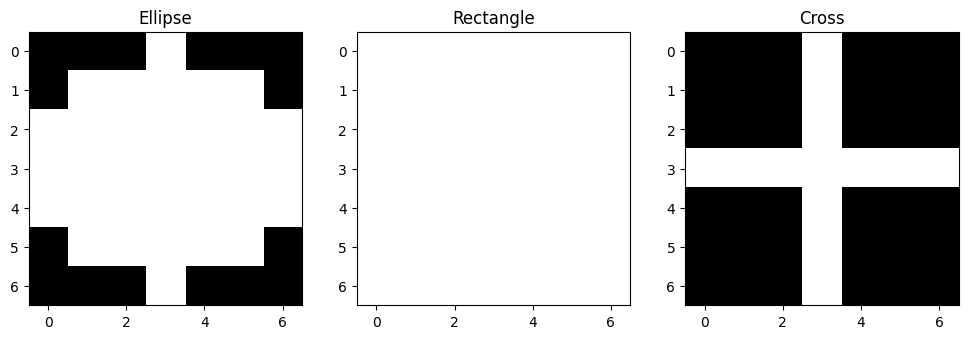

In [3]:
# Tamanho do elemento estruturante
kernel_size = (7, 7)

# Elemento estruturante de formato elíptico
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)

# Elemento estruturante de formato retangular
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)

# Elemento estruturante de formato cruz
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, kernel_size)

# Plotando os elementos estruturantes lado a lado
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(kernel_ellipse, cmap='gray', interpolation='none')
plt.title("Ellipse")

plt.subplot(1, 3, 2)
plt.imshow(kernel_rect, cmap='gray', interpolation='none', vmin=0, vmax=1)
plt.title("Rectangle")

plt.subplot(1, 3, 3)
plt.imshow(kernel_cross, cmap='gray', interpolation='none')
plt.title("Cross")

plt.show()

In [4]:
kernel_ellipse

array([[0, 0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0]], dtype=uint8)

## Dilation e Erosion no OpenCV

As função do OpenCV que executam as operações de dilatação e erosão são **`cv.dilate()`** e **`cv.erode`**. As sintaxes são fornecidas abaixo.

### <font style="color:rgb(8,133,37)">Sintaxes das Funções</font>

```python
dst = cv.dilate(src, kernel[, dst[, anchor[, iterations[, borderType[, borderValue]]]]])
```

```python
dst = cv.erode(src, kernel[, dst[, anchor[, iterations[, borderType[, borderValue]]]]])
```


**Parâmetros**

- **`src`** - Imagem de entrada; o número de canais pode ser arbitrário, mas a profundidade deve ser um de CV_8U, CV_16U, CV_16S, CV_32F ou CV_64F.
- **`kernel`** - Elemento estruturante usado para dilatação; se element=Mat(), um elemento estruturante retangular 3 x 3 é usado. O Kernel pode ser criado usando getStructuringElement.
- **`dst`** - Imagem de saída do mesmo tamanho e tipo que src.
- **`anchor`** - Posição da âncora dentro do elemento; o valor padrão (-1, -1) significa que a âncora está no centro do elemento.
- **`iterations`** - Número de vezes que a dilatação é aplicada.
- **`borderType`** - Método de extrapolação de pixel, veja BorderTypes. BORDER_WRAP não é suportado.
- **`borderValue`** - Valor de borda no caso de uma borda constante.

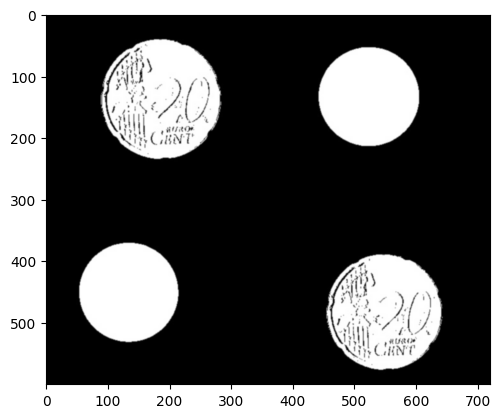

In [6]:
# Carregando as imagens para o processo de dilatação e erosão:
from calendar import c


dilation_moedas = cv2.imread("../../data/dilation_moedas.jpg")

# Plotar a imagem original
plt.imshow(dilation_moedas, cmap='gray')